In [1]:
import os

os.environ['PROJECT_DIR'] = '/Users/eden.yavin/Projects/Tabular-Cloud-ML'

In [18]:
DATASET_NAME = "agaricus_lepiota"

In [19]:
from src.dataset import DatasetFactory
raw_dataset = DatasetFactory().get_dataset(DATASET_NAME)
X, y = raw_dataset.get_dataset()
X.shape


Scaling numerical columns...


(8145, 22)

In [20]:
from src.utils.db import RawSplitDBFactory

X_train, X_test, X_sample, y_train, y_test, y_sample = RawSplitDBFactory.get_db(raw_dataset).get_split()
X_test.shape, X_sample.shape

2025-12-17 13:39:48.086 | INFO     | src.utils.db:get_split:82 - agaricus_lepiota LOADED INDEX 1.0 - INDEX SIZE 7330


((815, 22), (7330, 22))

In [21]:
from keras.src.utils import to_categorical

y_train =  to_categorical(y_train, num_classes=2)
y_test = to_categorical(y_test, num_classes=2)
y_sample = to_categorical(y_sample, num_classes=2)

In [22]:
X_sample.shape

(7330, 22)

In [23]:
from src.utils.traingulations import get_triangulation_samples_clustering, get_class_representative_samples

kmeans_tr = get_triangulation_samples_clustering(2, X_sample)
kmeans_tr.shape

(2, 22)

In [24]:
class_rep_tr = get_class_representative_samples(X_sample, y_sample)
class_rep_tr.shape

(2, 22)

In [25]:
from sklearn.decomposition import PCA
import numpy as np

X_all = np.vstack([X_sample, X_test, kmeans_tr, class_rep_tr])
# 3. Dimensionality Reduction (PCA)
pca = PCA(n_components=2)
X_embedded = pca.fit_transform(X_all)

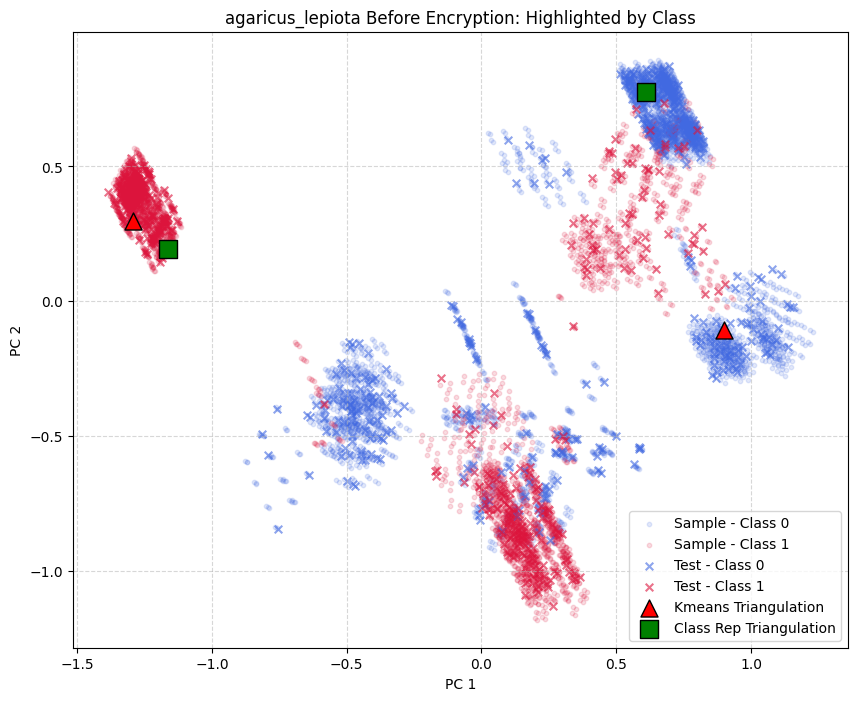

In [26]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Slice X_embedded (Using the logic you provided)
# Assuming X_embedded was created via PCA on the full raw dataset in the previous step
X_sample_2d = X_embedded[:X_sample.shape[0]]
X_test_2d = X_embedded[X_sample.shape[0]:X_sample.shape[0] + X_test.shape[0]]
kmeans_tr_2d = X_embedded[X_sample.shape[0] + X_test.shape[0]:X_sample.shape[0] + X_test.shape[0] +  2]
class_rep_tr_2d = X_embedded[X_sample.shape[0] + X_test.shape[0] + 2: X_sample.shape[0] + X_test.shape[0] + 2 + 2]

# 2. Prepare Labels
# Convert one-hot encoded labels back to indices (0 or 1)
# Note: In "Before Encryption", we usually plot the whole X_sample, so no slicing needed on y_sample
y_sample_labels = np.argmax(y_sample, axis=1)
y_test_labels = np.argmax(y_test, axis=1)

# 3. Define Colors
class_colors = {0: 'royalblue', 1: 'crimson'}
class_names = {0: 'Class 0', 1: 'Class 1'}

# 4. Plotting
fig = plt.figure(figsize=(10, 8), facecolor='white')
ax = plt.gca()
ax.set_facecolor('white')

# --- Plot Rest of Dataset (Sample) by Class ---
for cls in [0, 1]:
    mask = (y_sample_labels == cls)
    plt.scatter(
        X_sample_2d[mask, 0], X_sample_2d[mask, 1],
        c=class_colors[cls],
        alpha=0.15,
        s=10,
        label=f'Sample - {class_names[cls]}'
    )

# --- Plot Test Samples by Class ---
for cls in [0, 1]:
    mask = (y_test_labels == cls)
    plt.scatter(
        X_test_2d[mask, 0], X_test_2d[mask, 1],
        c=class_colors[cls],
        alpha=0.6,
        s=30,
        marker='x',
        label=f'Test - {class_names[cls]}'
    )

# --- Plot Triangulations ---
plt.scatter(kmeans_tr_2d[:, 0], kmeans_tr_2d[:, 1], c='red', marker='^', s=150,
            label='Kmeans Triangulation', edgecolors='black', zorder=10)

plt.scatter(class_rep_tr_2d[:, 0], class_rep_tr_2d[:, 1], c='green', marker='s', s=150,
            label='Class Rep Triangulation', edgecolors='black', zorder=5)

plt.title(f'{DATASET_NAME} Before Encryption: Highlighted by Class')
plt.xlabel('PC 1')
plt.ylabel('PC 2')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.savefig(f'{DATASET_NAME}_before.png', facecolor='white')
plt.show()

In [27]:
from src.embeddings import ClipEmbedding, DinoEmbedding
from src.cloud import CLOUD_MODELS, DEFAULT_CLOUD_OUTPUT_SHAPE
from src.encryptor import EncryptorFactory
import os
encryptor = EncryptorFactory.get_model(dataset_name=DATASET_NAME, output_shape=DEFAULT_CLOUD_OUTPUT_SHAPE)

# triangulation_embedding = ClipEmbedding()
triangulation_embedding = DinoEmbedding()

# 1. Enable MPS Fallback for unsupported operators
os.environ['PYTORCH_ENABLE_MPS_FALLBACK'] = '1'

In [28]:

y_tag1 = encryptor.encode(kmeans_tr)
y_tag2 = encryptor.encode(class_rep_tr)
# 2. Embed the encryption
y_tag_1emb = triangulation_embedding.forward(y_tag1)
y_tag_2emb = triangulation_embedding.forward(y_tag2)

In [29]:
from tqdm.notebook import tqdm
X_sample_enc, X_test_enc  = [], []
for x in tqdm(X_sample[:2000], leave=True, total=len(X_sample), position=0):
    x_tag = encryptor.encode(x.reshape(1, -1))
    X_sample_enc.append(triangulation_embedding.forward(np.vstack(x_tag)))
    encryptor.switch_key()

for x in tqdm(X_test, leave=True, total=len(X_test), position=0):
    x_tag = encryptor.encode(x.reshape(1, -1))
    X_test_enc.append(triangulation_embedding.forward(np.vstack(x_tag)))
    encryptor.switch_key()

X_sample_enc = np.vstack(X_sample_enc)
X_test_enc = np.vstack(X_test_enc)

  0%|          | 0/7330 [00:00<?, ?it/s]

  0%|          | 0/815 [00:00<?, ?it/s]

In [14]:
from sklearn.decomposition import PCA
import numpy as np

X_all_enc = np.vstack([X_sample_enc, X_test_enc, y_tag_1emb, y_tag_2emb])
# 3. Dimensionality Reduction (PCA)
pca = PCA(n_components=2)
X_embedded_enc = pca.fit_transform(X_all_enc)

Running PCA on shape: (3906, 768) ...


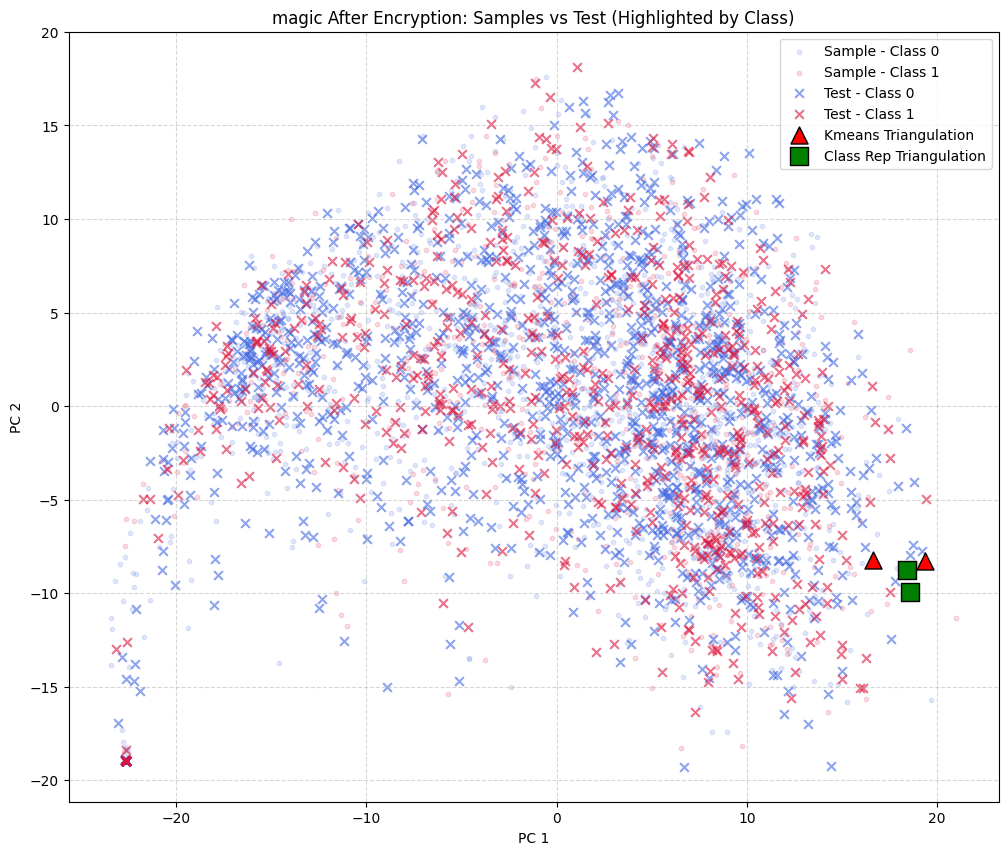

In [15]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# --- 1. Dimensionality Reduction (PCA) ---
# Stack all encrypted parts: Sample, Test, and Triangulations
# (Ensure y_tag_1emb and y_tag_2emb are available from previous steps)
X_all_enc = np.vstack([X_sample_enc, X_test_enc, y_tag_1emb, y_tag_2emb])

print(f"Running PCA on shape: {X_all_enc.shape} ...")
pca = PCA(n_components=2)
X_embedded_enc = pca.fit_transform(X_all_enc)

# --- 2. Slice back into components ---
n_sample = X_sample_enc.shape[0]
n_test = X_test_enc.shape[0]
n_kmeans = y_tag_1emb.shape[0]     # Typically 2
n_class_rep = y_tag_2emb.shape[0]  # Typically 2

# Slice indices
idx_sample_end = n_sample
idx_test_end = n_sample + n_test
idx_kmeans_end = idx_test_end + n_kmeans

X_sample_2d = X_embedded_enc[:idx_sample_end]
X_test_2d = X_embedded_enc[idx_sample_end:idx_test_end]
kmeans_tr_2d = X_embedded_enc[idx_test_end:idx_kmeans_end]
class_rep_tr_2d = X_embedded_enc[idx_kmeans_end:]

# --- 3. Prepare Labels ---
# Convert one-hot to indices (if not already done)
# Slice y_sample to match X_sample_enc size (if it was a subset)
y_sample_labels = np.argmax(y_sample[:n_sample], axis=1)
y_test_labels = np.argmax(y_test, axis=1)

# --- 4. Plotting ---
class_colors = {0: 'royalblue', 1: 'crimson'}
class_names = {0: 'Class 0', 1: 'Class 1'}

fig = plt.figure(figsize=(12, 10), facecolor='white')
ax = plt.gca()
ax.set_facecolor('white')

# Plot Sample Data (Separated by Class)
for cls in [0, 1]:
    mask = (y_sample_labels == cls)
    plt.scatter(
        X_sample_2d[mask, 0], X_sample_2d[mask, 1],
        c=class_colors[cls],
        alpha=0.15,
        s=10,
        label=f'Sample - {class_names[cls]}'
    )

# Plot Test Samples (Separated by Class)
for cls in [0, 1]:
    mask = (y_test_labels == cls)
    plt.scatter(
        X_test_2d[mask, 0], X_test_2d[mask, 1],
        c=class_colors[cls],
        alpha=0.6,
        s=40,
        marker='x',
        label=f'Test - {class_names[cls]}'
    )

# Plot Triangulations
plt.scatter(kmeans_tr_2d[:, 0], kmeans_tr_2d[:, 1], c='red', marker='^', s=150,
            label='Kmeans Triangulation', edgecolors='black', zorder=10)

plt.scatter(class_rep_tr_2d[:, 0], class_rep_tr_2d[:, 1], c='green', marker='s', s=150,
            label='Class Rep Triangulation', edgecolors='black', zorder=5)

# Decoration
plt.title(f'{DATASET_NAME} After Encryption: Samples vs Test (Highlighted by Class)')
plt.xlabel('PC 1')
plt.ylabel('PC 2')
plt.legend(loc='best')
plt.grid(True, linestyle='--', alpha=0.5)

plt.savefig(f'{DATASET_NAME}_after.png', facecolor='white')
plt.show()

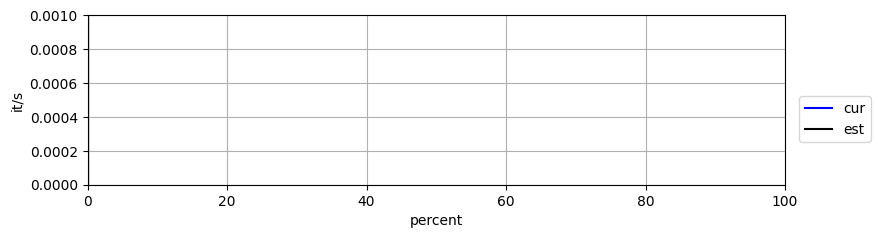

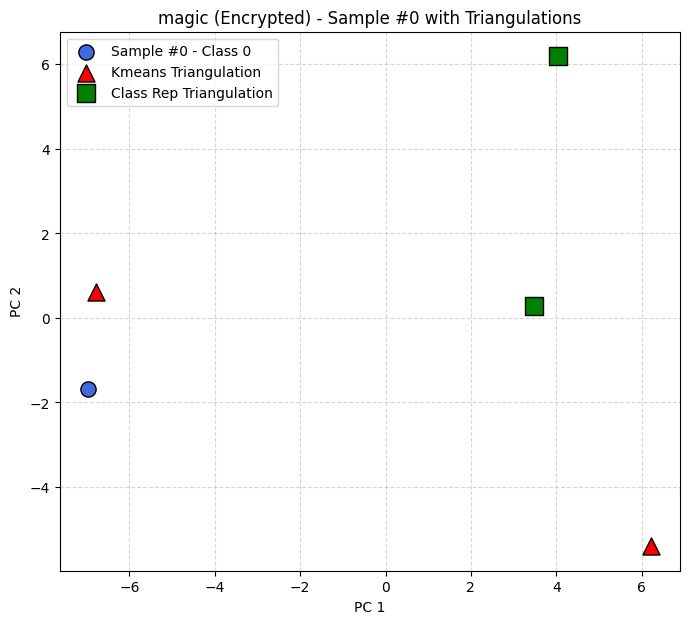

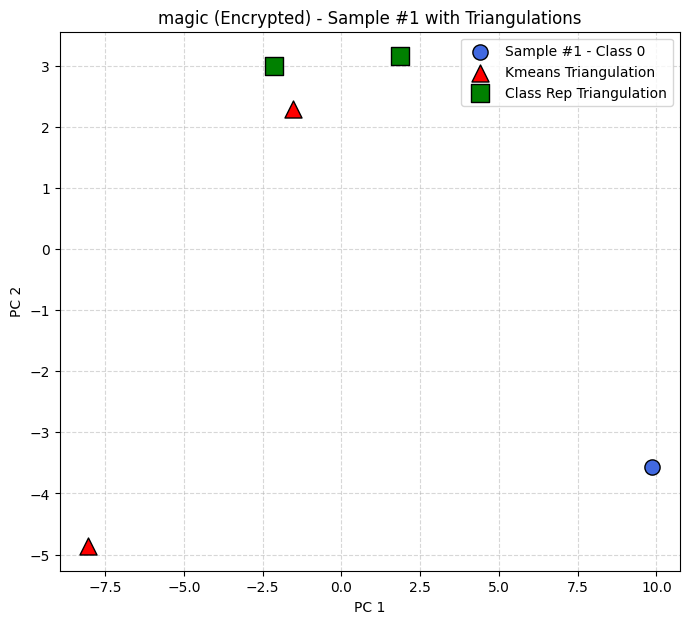

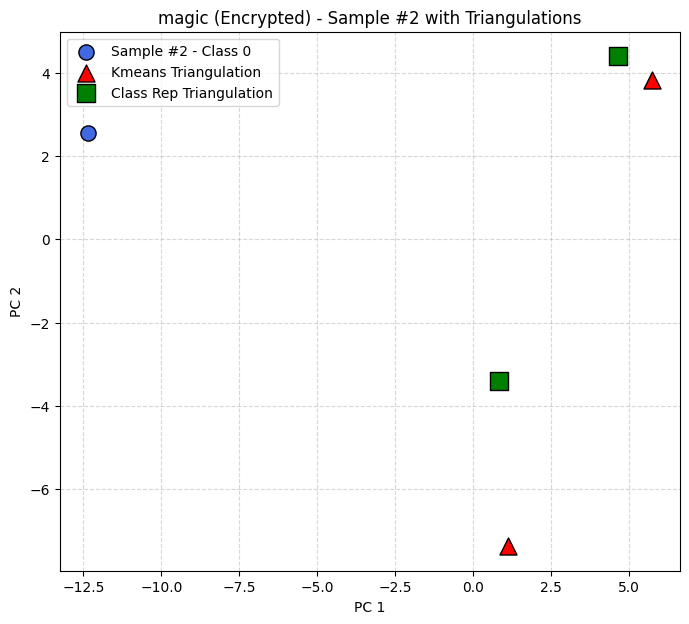

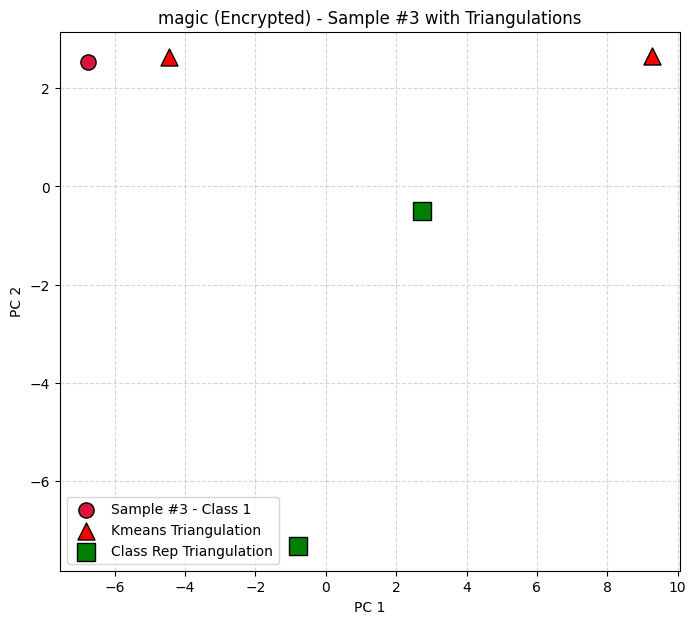

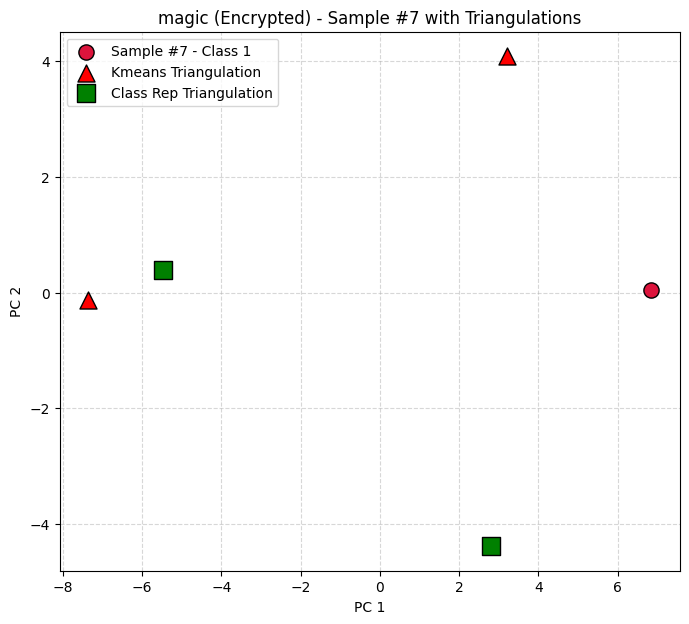

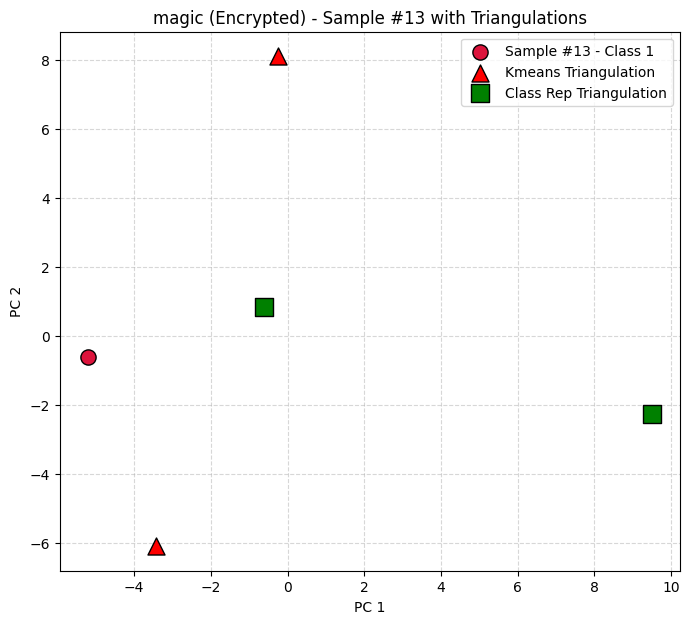

In [17]:
# Per-sample encrypted visualization with triangulations (iterate over 3 samples)
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from tqdm import tgrange
# Ensure output directory exists
plots_dir = os.path.join(os.getcwd(), 'plots', DATASET_NAME)
os.makedirs(plots_dir, exist_ok=True)

# Basic color/label mapping
class_colors = {0: 'royalblue', 1: 'crimson'}
class_names = {0: 'Class 0', 1: 'Class 1'}

"""Select up to 3 samples for each class to iterate over"""
# Support both one-hot and integer labels
if hasattr(y_sample, 'ndim') and y_sample.ndim > 1:
    y_sample_labels_loop = np.argmax(y_sample, axis=1)
else:
    y_sample_labels_loop = y_sample

selected_indices = []
for cls in [0, 1]:
    cls_indices = np.where(y_sample_labels_loop == cls)[0]
    # take up to 3 samples per class
    selected_indices.extend(list(cls_indices[:3]))

num_samples_to_plot = len(selected_indices)

for i in tgrange(num_samples_to_plot):
    idx = selected_indices[i]
    # 1) Encrypt & embed triangulations with current key
    y_tag1_i = encryptor.encode(kmeans_tr)
    y_tag2_i = encryptor.encode(class_rep_tr)
    y_tag_1emb_i = triangulation_embedding.forward(y_tag1_i)
    y_tag_2emb_i = triangulation_embedding.forward(y_tag2_i)

    # 2) Encrypt & embed the selected sample
    xi = X_sample[idx]
    xi_tag = encryptor.encode(xi.reshape(1, -1))
    xi_emb = triangulation_embedding.forward(np.vstack(xi_tag))  # shape (1, d)

    # 3) PCA on current sample + triangulations
    X_all_enc_i = np.vstack([xi_emb, y_tag_1emb_i, y_tag_2emb_i])
    pca_i = PCA(n_components=2)
    X_embedded_i = pca_i.fit_transform(X_all_enc_i)

    # Slices
    xi_2d = X_embedded_i[0:1]
    kmeans_tr_2d_i = X_embedded_i[1:1 + y_tag_1emb_i.shape[0]]
    class_rep_tr_2d_i = X_embedded_i[1 + y_tag_1emb_i.shape[0]:]

    # 4) Plot current sample with triangulations
    yi_cls = int(np.argmax(y_sample[idx])) if y_sample.ndim > 1 else int(y_sample[idx])

    fig = plt.figure(figsize=(8, 7), facecolor='white')
    ax = plt.gca()
    ax.set_facecolor('white')

    # Plot sample point
    plt.scatter(xi_2d[:, 0], xi_2d[:, 1], c=class_colors.get(yi_cls, 'gray'), s=120,
                edgecolors='black', linewidths=1.0, label=f'Sample #{idx} - {class_names.get(yi_cls, yi_cls)}', zorder=20)

    # Plot triangulations
    plt.scatter(kmeans_tr_2d_i[:, 0], kmeans_tr_2d_i[:, 1], c='red', marker='^', s=150,
                label='Kmeans Triangulation', edgecolors='black', zorder=10)

    plt.scatter(class_rep_tr_2d_i[:, 0], class_rep_tr_2d_i[:, 1], c='green', marker='s', s=150,
                label='Class Rep Triangulation', edgecolors='black', zorder=5)

    plt.title(f'{DATASET_NAME} (Encrypted) - Sample #{idx} with Triangulations')
    plt.xlabel('PC 1')
    plt.ylabel('PC 2')
    plt.legend(loc='best')
    plt.grid(True, linestyle='--', alpha=0.5)

    out_path = os.path.join(plots_dir, f'{DATASET_NAME}_sample_{idx}_encrypted.png')
    plt.savefig(out_path, facecolor='white')
    plt.show()

    # 5) Switch key before next iteration
    encryptor.switch_key()
